# Milestone 5: Formal Galactic Velocity Construction and Candidate Validation

This milestone builds on the larger Gaia–LAMOST feature table from Milestone 4, where metal-poor high-tangential-velocity candidates were selected using tangential-velocity and metallicity criteria.

Here, we extend the workflow by constructing 6D astrometric and radial-velocity based Galactocentric velocity diagnostics.

The goal is not to claim confirmed Galactic substructure membership, but to validate the candidate sample using formal velocity-space diagnostics.

Main tasks:

1. Load the Milestone 4 larger chemo-kinematic feature table.
2. Validate the required astrometric and radial-velocity input fields.
3. Construct 6D `SkyCoord` objects using Gaia astrometry and LAMOST radial velocities.
4. Transform coordinates to Galactic and Galactocentric frames.
5. Extract Galactocentric position and velocity components.
6. Build a velocity-enhanced feature table.
7. Extract and validate the chemo-kinematic candidate sample.
8. Generate report-ready diagnostic figures.

Important note:

The Galactocentric velocity components in this notebook use the default `astropy` Galactocentric frame parameters. They are used here for workflow-level velocity diagnostics and candidate validation, not for final orbit/action-based Galactic dynamics conclusions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy
import astropy.units as u
from astropy.coordinates import SkyCoord, Galactocentric

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

INPUT_FEATURE_TABLE = DATA_PROCESSED / "gaia_lamost_larger_chemo_kinematic_features.csv"

VELOCITY_FEATURE_TABLE = DATA_PROCESSED / "gaia_lamost_larger_velocity_features.csv"
CANDIDATE_TABLE = DATA_PROCESSED / "gaia_lamost_larger_chemo_kinematic_candidates.csv"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Astropy version:", astropy.__version__)
print("Input table:", INPUT_FEATURE_TABLE)

Project root: /Users/liors/Documents/gaia-lamost-galactic-archaeology
Astropy version: 7.2.0
Input table: /Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_chemo_kinematic_features.csv


In [3]:
df = pd.read_csv(INPUT_FEATURE_TABLE)

print("Milestone 4 feature table shape:", df.shape)
df.head()

Milestone 4 feature table shape: (1838, 38)


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,coord_match_sep_arcsec,pm_total,tangential_velocity_kms,reduced_pm_g,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate,gal_l,gal_b
0,3089803084812330368,123.585870,1.280288,1.355037,82.269290,-0.344946,0.219658,13.662231,0.734339,1.068794,...,0.001647,0.408947,1.430662,1.720566,solar_like,False,False,False,221.534140,18.970509
1,3090685683412224256,121.883921,1.744536,0.136420,7.009696,-1.741048,0.012936,14.192523,1.126508,1.023537,...,0.002247,1.741096,60.501583,5.396636,solar_like,False,False,False,220.257275,17.689465
2,3083676090627788288,121.847440,0.277612,0.523568,35.365410,-2.656724,1.883511,12.664207,1.156867,0.990327,...,0.002656,3.256653,29.486248,5.228065,solar_like,False,False,False,221.593783,16.964606
3,3083712438932111488,122.455011,0.252453,0.673550,27.477602,-1.330628,-1.522767,13.710716,0.630355,1.155529,...,0.002680,2.022224,14.232481,5.239863,solar_like,False,False,False,221.919714,17.486961
4,3084883801071606528,120.988708,1.818766,0.578844,21.939972,-1.409557,1.102854,14.830486,0.677205,1.069091,...,0.004176,1.789731,14.657079,6.094425,solar_like,False,False,False,219.749788,16.933549


## Input Field Validation

Before constructing 6D coordinates, we validate that the required astrometric and radial-velocity fields are present and usable.

The velocity construction requires:

- sky position: `ra_gaia`, `dec_gaia`
- distance proxy: `distance_pc`
- proper motion: `pmra`, `pmdec`
- radial velocity: `rv`

Here, `pmra` is treated as Gaia's `pm_ra_cosdec`, which is the convention expected by `astropy.coordinates.SkyCoord`.

In [4]:
required_columns = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "parallax",
    "distance_pc",
    "pmra",
    "pmdec",
    "rv",
    "bp_rp",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "feh",
    "logg",
    "teff",
    "pm_total",
    "tangential_velocity_kms",
    "reduced_pm_g",
    "metallicity_group",
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate",
    "gal_l",
    "gal_b",
    "coord_match_sep_arcsec",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")
print("Number of required columns:", len(required_columns))

All required columns are present.
Number of required columns: 24


In [5]:
velocity_input_columns = [
    "ra_gaia",
    "dec_gaia",
    "distance_pc",
    "parallax",
    "pmra",
    "pmdec",
    "rv",
]

validation_summary = pd.DataFrame({
    "missing_count": df[velocity_input_columns].isna().sum(),
    "dtype": df[velocity_input_columns].dtypes.astype(str),
})

validation_summary

,missing_count,dtype
ra_gaia,0,float64
dec_gaia,0,float64
distance_pc,0,float64
parallax,0,float64
pmra,0,float64
pmdec,0,float64
rv,0,float64


In [6]:
numeric_velocity_inputs = df[velocity_input_columns].apply(pd.to_numeric, errors="coerce")

numeric_validation_summary = pd.DataFrame({
    "missing_or_non_numeric_count": numeric_velocity_inputs.isna().sum(),
    "min": numeric_velocity_inputs.min(),
    "max": numeric_velocity_inputs.max(),
    "mean": numeric_velocity_inputs.mean(),
})

numeric_validation_summary

,missing_or_non_numeric_count,min,max,mean
ra_gaia,0,120.002072,124.995865,122.455871
dec_gaia,0,0.001824,1.999927,1.044276
distance_pc,0,99.120297,13193.564091,1303.752706
parallax,0,0.075795,10.088751,1.325033
pmra,0,-75.862201,39.171390,-3.772749
pmdec,0,-74.081247,33.408061,-3.276248
rv,0,-76.140000,385.540000,29.674434


In [7]:
invalid_distance_count = (numeric_velocity_inputs["distance_pc"] <= 0).sum()
invalid_parallax_count = (numeric_velocity_inputs["parallax"] <= 0).sum()

print("Invalid distance_pc <= 0:", invalid_distance_count)
print("Invalid parallax <= 0:", invalid_parallax_count)

if invalid_distance_count > 0 or invalid_parallax_count > 0:
    raise ValueError("Invalid non-positive distance or parallax values found.")

print("Velocity input sanity check passed.")

Invalid distance_pc <= 0: 0
Invalid parallax <= 0: 0
Velocity input sanity check passed.


## 6D SkyCoord Construction

We now construct 6D ICRS coordinates using Gaia positions, Gaia proper motions, distance estimates from parallax inversion, and LAMOST radial velocities.

In this step:

- `ra_gaia` and `dec_gaia` are treated as ICRS coordinates in degrees.
- `distance_pc` is used as the distance estimate in parsecs.
- `pmra` is passed to `pm_ra_cosdec`, following the Gaia convention.
- `pmdec` is passed to `pm_dec`.
- `rv` is passed as the line-of-sight radial velocity in km/s.

In [8]:
coords_icrs = SkyCoord(
    ra=df["ra_gaia"].values * u.deg,
    dec=df["dec_gaia"].values * u.deg,
    distance=df["distance_pc"].values * u.pc,
    pm_ra_cosdec=df["pmra"].values * u.mas / u.yr,
    pm_dec=df["pmdec"].values * u.mas / u.yr,
    radial_velocity=df["rv"].values * u.km / u.s,
    frame="icrs",
)

coords_icrs[:5]

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(123.58586976, 1.28028819,  737.98717914),
     (121.88392108, 1.74453645, 7330.31559108),
     (121.84743989, 0.27761167, 1909.97007606),
     (122.45501066, 0.25245275, 1484.66999993),
     (120.98870759, 1.81876592, 1727.58017199)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-0.3449462 ,  0.21965818, 22.46), (-1.74104773,  0.01293632, 96.55),
     (-2.65672352,  1.88351056, 69.04), (-1.33062833, -1.5227668 , 23.39),
     (-1.40955707,  1.10285398, 80.68)]>

## Galactic Coordinate Consistency Check

Milestone 4 already added Galactic longitude and latitude columns. Here we recompute Galactic coordinates using `astropy` from the full 6D `SkyCoord` object and compare them with the stored Milestone 4 values.

The longitude difference is computed with 0/360-degree wrapping handled explicitly.

In [9]:
coords_galactic = coords_icrs.galactic

df["gal_l_astropy"] = coords_galactic.l.deg
df["gal_b_astropy"] = coords_galactic.b.deg

l_diff = ((df["gal_l_astropy"] - df["gal_l"] + 180) % 360) - 180
b_diff = df["gal_b_astropy"] - df["gal_b"]

print("Max |l difference|:", np.max(np.abs(l_diff)))
print("Max |b difference|:", np.max(np.abs(b_diff)))

pd.DataFrame({
    "l_diff_deg": l_diff,
    "b_diff_deg": b_diff,
}).describe()

Max |l difference|: 5.684341886080802e-14
Max |b difference|: 4.618527782440651e-14


,l_diff_deg,b_diff_deg
count,1.838000e+03,1.838000e+03
mean,3.556580e-16,-8.698156e-18
std,1.979084e-14,1.343717e-14
min,-5.684342e-14,-4.618528e-14
25%,0.000000e+00,-7.105427e-15
50%,0.000000e+00,0.000000e+00
75%,0.000000e+00,7.105427e-15
max,5.684342e-14,4.618528e-14


## Galactocentric Frame Transformation

We now transform the 6D ICRS coordinates into the `astropy` Galactocentric frame.

The Galactocentric Cartesian position and velocity components are used here as workflow-level velocity diagnostics. The frame assumptions depend on the default `astropy` Galactocentric parameters used by the installed version, so we explicitly record the frame object below.

These velocity components should not be interpreted as final orbit-based Galactic dynamics results.

In [11]:
galactocentric_frame = Galactocentric()

print("Astropy version:", astropy.__version__)
print("Galactocentric frame:")
print(galactocentric_frame)

Astropy version: 7.2.0
Galactocentric frame:
<Galactocentric Frame (galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg)>


In [12]:
coords_galcen = coords_icrs.transform_to(galactocentric_frame)

coords_galcen[:5]

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in pc
    [( -8643.78171249,  -462.75653158,  262.04161893),
     (-13445.88724096, -4513.02336797, 2261.80151681),
     ( -9486.79619771, -1212.75027702,  581.58614054),
     ( -9174.49070096,  -946.05089896,  469.62063804),
     ( -9391.33406275, -1056.78150413,  527.22820323)]
 (v_x, v_y, v_z) in km / s
    [( -3.98045063, 232.3011187 ,  14.46494864),
     (-88.29098963, 197.67018971, -13.32596395),
     (-56.86588413, 219.00410623,  15.61201414),
     ( -3.38555983, 224.3288867 ,   2.12527209),
     (-56.29071489, 205.41845567,  25.72939797)]>

## Galactocentric Position and Velocity Components

We extract Galactocentric Cartesian position and velocity components from the transformed coordinates.

The resulting velocity components are:

- `galcen_vx_kms`
- `galcen_vy_kms`
- `galcen_vz_kms`

We also compute:

- `galcen_vtot_kms`

as the Euclidean magnitude of the Galactocentric velocity vector.

This total velocity is defined in the Galactocentric frame and should not be confused with the heliocentric tangential velocity proxy used in Milestone 4.

In [13]:
df["galcen_x_kpc"] = coords_galcen.x.to(u.kpc).value
df["galcen_y_kpc"] = coords_galcen.y.to(u.kpc).value
df["galcen_z_kpc"] = coords_galcen.z.to(u.kpc).value

df["galcen_vx_kms"] = coords_galcen.v_x.to(u.km / u.s).value
df["galcen_vy_kms"] = coords_galcen.v_y.to(u.km / u.s).value
df["galcen_vz_kms"] = coords_galcen.v_z.to(u.km / u.s).value

df["galcen_vtot_kms"] = np.sqrt(
    df["galcen_vx_kms"] ** 2
    + df["galcen_vy_kms"] ** 2
    + df["galcen_vz_kms"] ** 2
)

velocity_columns = [
    "galcen_x_kpc",
    "galcen_y_kpc",
    "galcen_z_kpc",
    "galcen_vx_kms",
    "galcen_vy_kms",
    "galcen_vz_kms",
    "galcen_vtot_kms",
]

df[velocity_columns].describe()

,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,galcen_vtot_kms
count,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000,1838.000000
mean,-9.055732,-0.816212,0.421296,-11.517236,221.245714,-2.100720,227.343279
std,0.826659,0.715392,0.346959,40.202124,34.005870,22.348512,25.930892
min,-17.419042,-8.397720,0.048296,-236.400018,-277.157733,-379.513041,31.849315
25%,-9.349417,-1.073873,0.203766,-36.839784,210.527611,-13.368363,215.471496
50%,-8.806459,-0.596886,0.314215,-12.801839,225.463796,-2.065301,229.728926
75%,-8.553134,-0.376410,0.552820,12.170732,239.391536,9.885094,243.133636
max,-8.193473,-0.062901,4.157578,239.576587,285.246451,90.450959,393.357104


In [14]:
velocity_component_summary = pd.DataFrame({
    "missing_count": df[velocity_columns].isna().sum(),
    "min": df[velocity_columns].min(),
    "max": df[velocity_columns].max(),
    "mean": df[velocity_columns].mean(),
    "std": df[velocity_columns].std(),
})

velocity_component_summary

,missing_count,min,max,mean,std
galcen_x_kpc,0,-17.419042,-8.193473,-9.055732,0.826659
galcen_y_kpc,0,-8.397720,-0.062901,-0.816212,0.715392
galcen_z_kpc,0,0.048296,4.157578,0.421296,0.346959
galcen_vx_kms,0,-236.400018,239.576587,-11.517236,40.202124
galcen_vy_kms,0,-277.157733,285.246451,221.245714,34.005870
galcen_vz_kms,0,-379.513041,90.450959,-2.100720,22.348512
galcen_vtot_kms,0,31.849315,393.357104,227.343279,25.930892


## Save Velocity-enhanced Feature Table

We save the Milestone 5 velocity-enhanced feature table. This table preserves the Milestone 4 chemo-kinematic features and adds Galactic/Galactocentric coordinate and velocity diagnostics.

In [15]:
df.to_csv(VELOCITY_FEATURE_TABLE, index=False)

print("Saved velocity-enhanced feature table:")
print(VELOCITY_FEATURE_TABLE)
print("Shape:", df.shape)

Saved velocity-enhanced feature table:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_velocity_features.csv
Shape: (1838, 47)


## Candidate Table Extraction

We now extract the Milestone 4 chemo-kinematic candidates from the velocity-enhanced feature table.

These candidates are selected using the existing `chemo_kinematic_candidate` flag. They should be interpreted as metal-poor high-tangential-velocity candidates requiring further validation, not as confirmed halo stars or confirmed substructure members.

In [16]:
candidate_df = df[df["chemo_kinematic_candidate"] == True].copy()

print("Number of chemo-kinematic candidates:", len(candidate_df))
candidate_df.head()

Number of chemo-kinematic candidates: 27


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,gal_b,gal_l_astropy,gal_b_astropy,galcen_x_kpc,galcen_y_kpc,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,galcen_vtot_kms
132,3084618814470882048,121.206776,1.036917,0.239175,6.344524,-4.066020,-7.270800,15.836410,1.171156,0.939688,...,16.759371,220.578098,16.759371,-11.159579,-2.604178,1.234190,-52.362524,72.487760,-88.384340,125.730270
430,3077610566011025408,124.849144,0.784451,0.160951,8.252119,-2.328929,2.485346,13.772771,1.175033,0.964798,...,19.843864,222.635197,19.843864,-12.415988,-3.958398,2.140867,-123.879403,251.688003,16.328023,280.997440
456,3083553117121981312,123.113104,0.459705,0.075795,5.369841,0.459900,-3.770011,13.163137,1.549932,1.094676,...,18.164211,222.058099,18.164211,-17.419042,-8.397720,4.157578,76.094271,5.180934,-46.809029,89.488912
535,3083753361380495744,122.455722,0.527457,0.592972,41.151830,-8.172452,-11.732228,12.531010,1.146106,0.939714,...,17.618518,221.666424,17.618518,-9.321373,-1.068531,0.534312,-65.566197,107.044740,-51.287121,135.601885
570,3084618646970633984,121.170175,1.004626,0.154221,9.626410,-2.365713,2.503888,13.638368,1.100372,1.078928,...,16.711882,220.589852,16.711882,-12.833239,-4.040693,1.897454,-131.133907,256.692474,9.683853,288.411000


In [17]:
candidate_columns = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "gal_l",
    "gal_b",
    "gal_l_astropy",
    "gal_b_astropy",
    "parallax",
    "distance_pc",
    "bp_rp",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "teff",
    "logg",
    "feh",
    "rv",
    "pm_total",
    "tangential_velocity_kms",
    "reduced_pm_g",
    "galcen_x_kpc",
    "galcen_y_kpc",
    "galcen_z_kpc",
    "galcen_vx_kms",
    "galcen_vy_kms",
    "galcen_vz_kms",
    "galcen_vtot_kms",
    "metallicity_group",
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate",
    "coord_match_sep_arcsec",
]

missing_candidate_columns = [
    col for col in candidate_columns if col not in candidate_df.columns
]

if missing_candidate_columns:
    raise ValueError(f"Missing candidate columns: {missing_candidate_columns}")

candidate_table = candidate_df[candidate_columns].copy()

print("Candidate table shape:", candidate_table.shape)
candidate_table.head()

Candidate table shape: (27, 31)


,source_id,ra_gaia,dec_gaia,gal_l,gal_b,gal_l_astropy,gal_b_astropy,parallax,distance_pc,bp_rp,...,galcen_z_kpc,galcen_vx_kms,galcen_vy_kms,galcen_vz_kms,galcen_vtot_kms,metallicity_group,high_vtan_candidate,metal_poor_candidate,chemo_kinematic_candidate,coord_match_sep_arcsec
132,3084618814470882048,121.206776,1.036917,220.578098,16.759371,220.578098,16.759371,0.239175,4181.041412,1.171156,...,1.234190,-52.362524,72.487760,-88.384340,125.730270,metal_poor,True,True,True,0.028884
430,3077610566011025408,124.849144,0.784451,222.635197,19.843864,222.635197,19.843864,0.160951,6213.063298,1.175033,...,2.140867,-123.879403,251.688003,16.328023,280.997440,metal_poor,True,True,True,0.056867
456,3083553117121981312,123.113104,0.459705,222.058099,18.164211,222.058099,18.164211,0.075795,13193.564091,1.549932,...,4.157578,76.094271,5.180934,-46.809029,89.488912,metal_poor,True,True,True,0.058795
535,3083753361380495744,122.455722,0.527457,221.666424,17.618518,221.666424,17.618518,0.592972,1686.420193,1.146106,...,0.534312,-65.566197,107.044740,-51.287121,135.601885,metal_poor,True,True,True,0.064145
570,3084618646970633984,121.170175,1.004626,220.589852,16.711882,220.589852,16.711882,0.154221,6484.216392,1.100372,...,1.897454,-131.133907,256.692474,9.683853,288.411000,metal_poor,True,True,True,0.066554


In [18]:
candidate_table.to_csv(CANDIDATE_TABLE, index=False)

print("Saved candidate table:")
print(CANDIDATE_TABLE)
print("Shape:", candidate_table.shape)

Saved candidate table:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_chemo_kinematic_candidates.csv
Shape: (27, 31)


## Milestone 5 Validation Figures

We generate validation figures for the velocity-enhanced larger Gaia–LAMOST sample and the selected chemo-kinematic candidates.

The figures are intended for diagnostic and report-preparation purposes. They are not used to claim confirmed stellar population membership.

In [19]:
def save_current_figure(output_path):
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    plt.show()

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_galcen_velocity_distribution.png


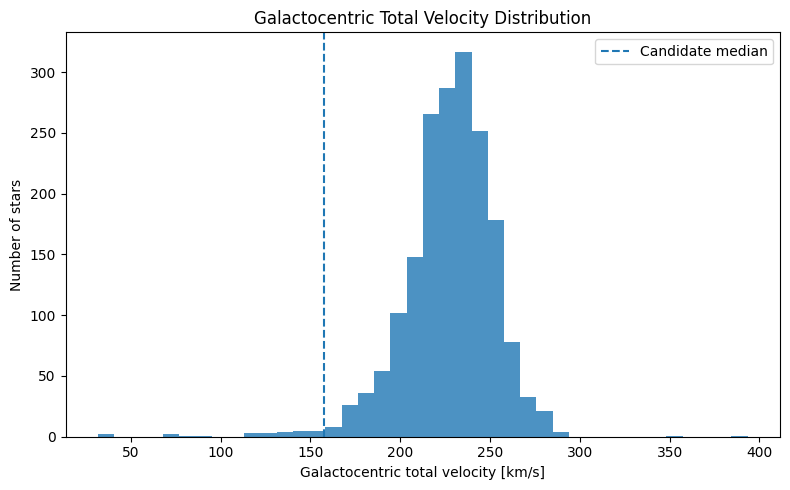

In [20]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_galcen_velocity_distribution.png"

plt.figure(figsize=(8, 5))
plt.hist(df["galcen_vtot_kms"], bins=40, alpha=0.8)
plt.axvline(
    candidate_table["galcen_vtot_kms"].median(),
    linestyle="--",
    label="Candidate median"
)

plt.xlabel("Galactocentric total velocity [km/s]")
plt.ylabel("Number of stars")
plt.title("Galactocentric Total Velocity Distribution")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_galcen_vx_vy.png


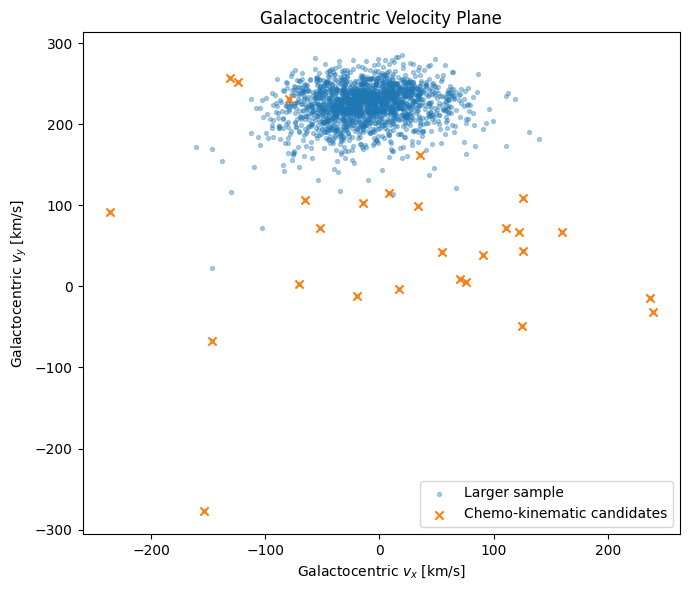

In [21]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_galcen_vx_vy.png"

plt.figure(figsize=(7, 6))
plt.scatter(
    df["galcen_vx_kms"],
    df["galcen_vy_kms"],
    s=8,
    alpha=0.35,
    label="Larger sample"
)
plt.scatter(
    candidate_table["galcen_vx_kms"],
    candidate_table["galcen_vy_kms"],
    s=35,
    marker="x",
    label="Chemo-kinematic candidates"
)

plt.xlabel("Galactocentric $v_x$ [km/s]")
plt.ylabel("Galactocentric $v_y$ [km/s]")
plt.title("Galactocentric Velocity Plane")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_galcen_vtot_vs_feh.png


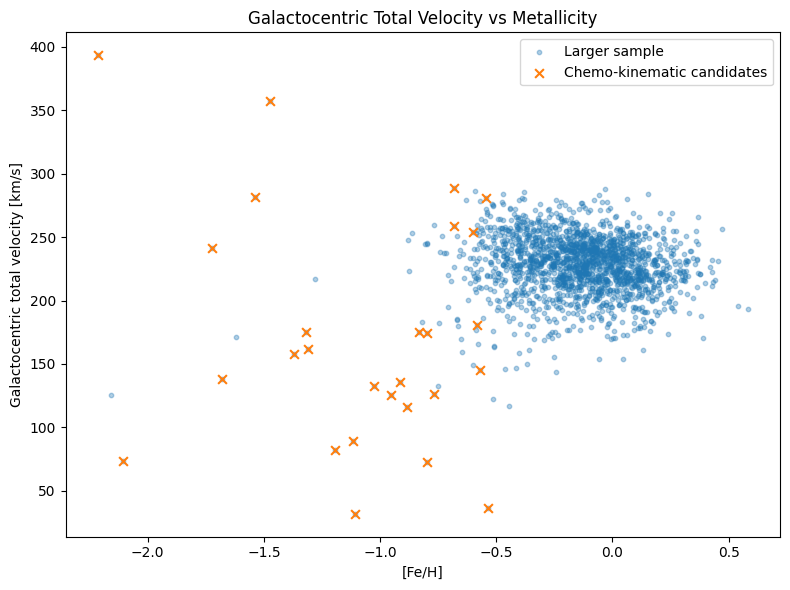

In [22]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_galcen_vtot_vs_feh.png"

plt.figure(figsize=(8, 6))
plt.scatter(
    df["feh"],
    df["galcen_vtot_kms"],
    s=10,
    alpha=0.35,
    label="Larger sample"
)
plt.scatter(
    candidate_table["feh"],
    candidate_table["galcen_vtot_kms"],
    s=40,
    marker="x",
    label="Chemo-kinematic candidates"
)

plt.xlabel("[Fe/H]")
plt.ylabel("Galactocentric total velocity [km/s]")
plt.title("Galactocentric Total Velocity vs Metallicity")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_candidates_vtan_vs_feh.png


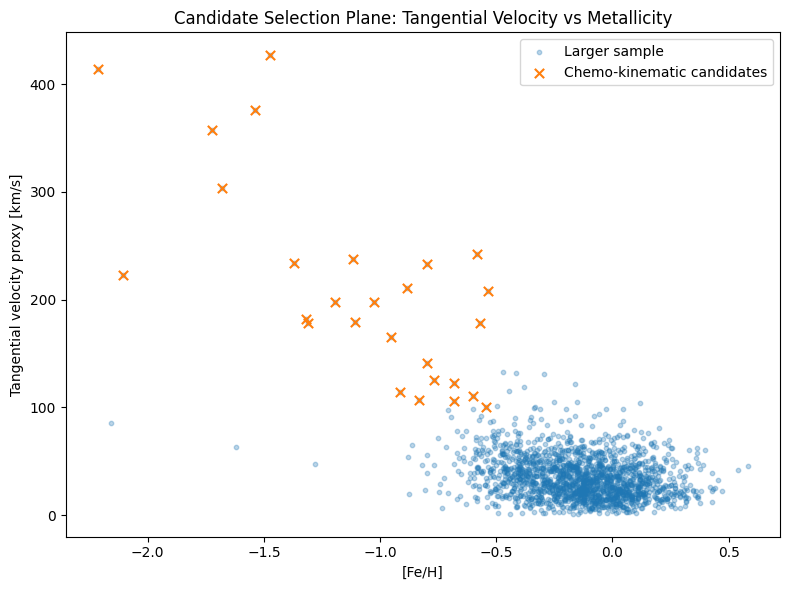

In [23]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_candidates_vtan_vs_feh.png"

plt.figure(figsize=(8, 6))
plt.scatter(
    df["feh"],
    df["tangential_velocity_kms"],
    s=10,
    alpha=0.3,
    label="Larger sample"
)
plt.scatter(
    candidate_table["feh"],
    candidate_table["tangential_velocity_kms"],
    s=45,
    marker="x",
    label="Chemo-kinematic candidates"
)

plt.xlabel("[Fe/H]")
plt.ylabel("Tangential velocity proxy [km/s]")
plt.title("Candidate Selection Plane: Tangential Velocity vs Metallicity")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_candidates_cmd.png


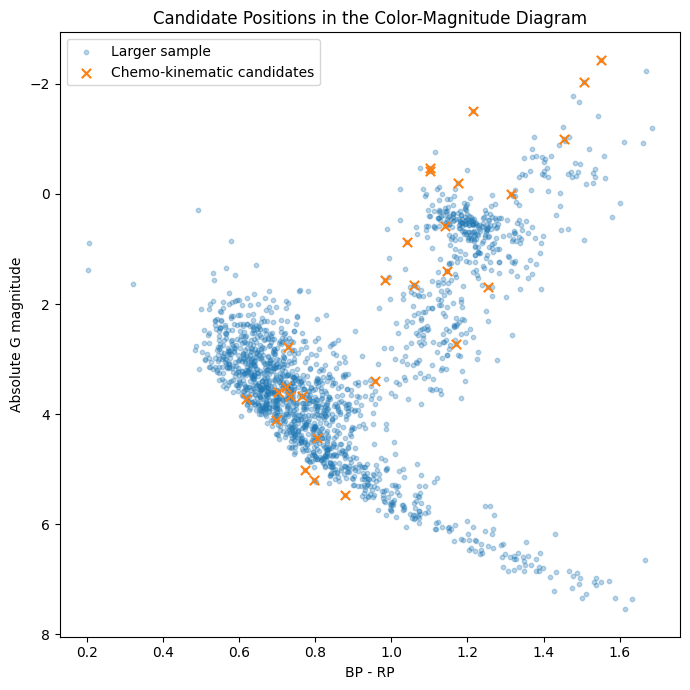

In [24]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_candidates_cmd.png"

plt.figure(figsize=(7, 7))
plt.scatter(
    df["bp_rp"],
    df["absolute_g_mag"],
    s=10,
    alpha=0.3,
    label="Larger sample"
)
plt.scatter(
    candidate_table["bp_rp"],
    candidate_table["absolute_g_mag"],
    s=45,
    marker="x",
    label="Chemo-kinematic candidates"
)

plt.gca().invert_yaxis()
plt.xlabel("BP - RP")
plt.ylabel("Absolute G magnitude")
plt.title("Candidate Positions in the Color-Magnitude Diagram")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_candidates_sky_galactic.png


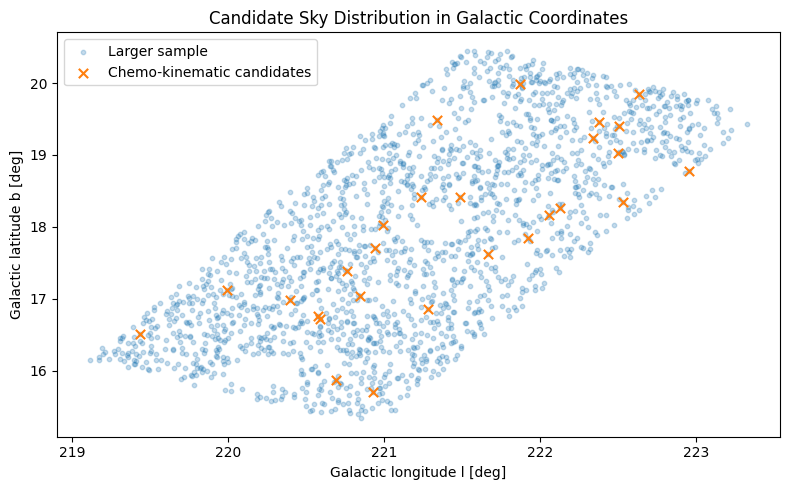

In [25]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_candidates_sky_galactic.png"

plt.figure(figsize=(8, 5))
plt.scatter(
    df["gal_l"],
    df["gal_b"],
    s=10,
    alpha=0.25,
    label="Larger sample"
)
plt.scatter(
    candidate_table["gal_l"],
    candidate_table["gal_b"],
    s=45,
    marker="x",
    label="Chemo-kinematic candidates"
)

plt.xlabel("Galactic longitude l [deg]")
plt.ylabel("Galactic latitude b [deg]")
plt.title("Candidate Sky Distribution in Galactic Coordinates")
plt.legend()

save_current_figure(fig_path)

Saved figure: /Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_candidates_rv_distribution.png


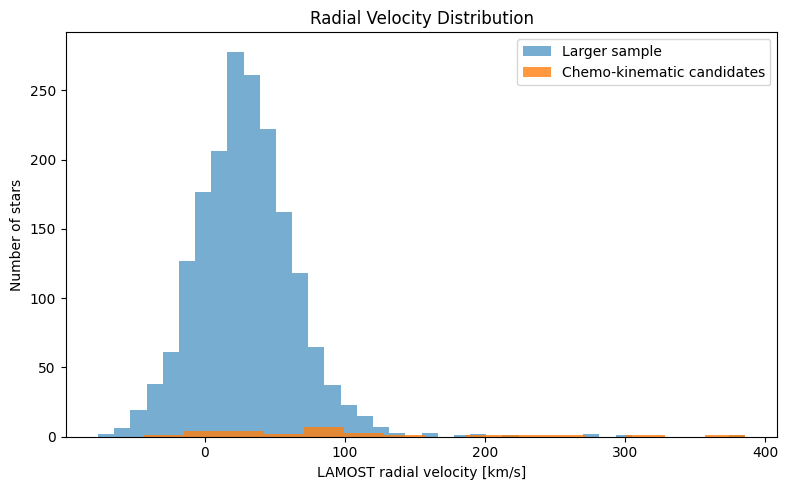

In [26]:
fig_path = FIGURES_DIR / "gaia_lamost_larger_candidates_rv_distribution.png"

plt.figure(figsize=(8, 5))
plt.hist(
    df["rv"],
    bins=40,
    alpha=0.6,
    label="Larger sample"
)
plt.hist(
    candidate_table["rv"],
    bins=15,
    alpha=0.8,
    label="Chemo-kinematic candidates"
)

plt.xlabel("LAMOST radial velocity [km/s]")
plt.ylabel("Number of stars")
plt.title("Radial Velocity Distribution")
plt.legend()

save_current_figure(fig_path)

## Milestone 5 Summary

Milestone 5 constructed formal Galactocentric velocity diagnostics for the larger Gaia–LAMOST chemo-kinematic sample.

Starting from the Milestone 4 larger feature table, this notebook validated the required astrometric and radial-velocity input fields, constructed 6D `SkyCoord` objects using Gaia astrometry and LAMOST radial velocities, and transformed the sample into Galactic and Galactocentric coordinate frames.

The stored Milestone 4 Galactic coordinates were verified against newly computed `astropy` Galactic coordinates, with differences consistent with numerical precision.

Using the default `astropy` Galactocentric frame parameters, this notebook extracted Galactocentric Cartesian position and velocity components and computed the total Galactocentric velocity diagnostic.

Generated data products:

- `data/processed/gaia_lamost_larger_velocity_features.csv`
- `data/processed/gaia_lamost_larger_chemo_kinematic_candidates.csv`

Generated validation figures:

- `figures/gaia_lamost_larger_galcen_velocity_distribution.png`
- `figures/gaia_lamost_larger_galcen_vx_vy.png`
- `figures/gaia_lamost_larger_galcen_vtot_vs_feh.png`
- `figures/gaia_lamost_larger_candidates_vtan_vs_feh.png`
- `figures/gaia_lamost_larger_candidates_cmd.png`
- `figures/gaia_lamost_larger_candidates_sky_galactic.png`
- `figures/gaia_lamost_larger_candidates_rv_distribution.png`

Candidate validation result:

The Milestone 4 chemo-kinematic candidate sample contains 27 metal-poor high-tangential-velocity candidates. These candidates occupy distinct regions in metallicity-velocity diagnostic space and remain useful targets for further validation.

Interpretation note:

The Galactocentric velocity components are used here for workflow-level velocity diagnostics. The candidate sample should not be interpreted as confirmed halo stars, confirmed merger debris, or confirmed Galactic substructure members without further orbit/action-space analysis and a more complete treatment of selection effects.